# Pretraitement et analyse exploratoire des donnees

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk spacy wordcloud langdetect

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [2]:
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 7.4 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 5.8 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 6.8 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 6.9 MB/s eta 0:00:02
     ----------------------- ---------------- 7.6/12.8 MB 7.1 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.8 MB 7.2 MB/s eta 0:00:01
     --------------------------------- ------ 10.7/12.8 MB 7.3 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.8 MB 7.2 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 7.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
     --- ------------------------------------ 1.3/16.3 MB 7.5 MB/s eta 0:00:02
     ------- -------------------------------- 2.9/16.3 MB 7.6 MB/s eta 0:00:02
     ----------- ---------------------------- 4.7/16.3 MB 7.5 MB/s eta 0:00:02
     -------------- ------------------------- 6.0/16.3 MB 7.4 MB/s eta 0:00:02
     ------------------- -------------------- 7.9/16.3 MB 7.4 MB/s eta 0:00:02
     ----------------------- ---------------- 9.4/16.3 MB 7.4 MB/s eta 0:00:01
     --------------------------- ------------ 11.0/16.3 MB 7.5 MB/s eta 0:00:01
     ------------------------------ --------- 12.6/16.3 MB 7.4 MB/s eta 0:00:01
     ---------------------------------- ----- 13.9/16.3 MB 7.3 MB/s eta 0:00:01
     -------------------------------------- - 15.7/16.3 MB 7.4 MB/s eta 0:00:01
     ---------------------------------------- 16.3/16.3 MB 7.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now loa


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# import des bibliotheques necessaires
%pip install langdetect
import pandas as pd
from pathlib import Path
from spacy.lang.fr.stop_words import STOP_WORDS as FR_STOP
from spacy.lang.en.stop_words import STOP_WORDS as EN_STOP
import unicodedata
from langdetect import detect
import re


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
DATA_PATH = Path('../data/all_comments_ottawa.csv')
df = pd.read_csv(DATA_PATH)

print('Apercu des donnees brutes:')
df.head()

Apercu des donnees brutes:


,Chambre confortable mais décoration un peu démodée. Le petit-déjeuner est bon mais sans originalité particulière.
0,Le spa propose un traitement signature exclusi...
1,Un séjour correct mais qui ne justifie pas ple...
2,The laundry service express saved our gala din...
3,L'exposition de collection d'art contemporain ...
4,L'emplacement privilégié est parfait pour expl...


In [5]:
# Assigner une colonne aux avis
df.columns = ['avis_clients']
df.head()

,avis_clients
0,Le spa propose un traitement signature exclusi...
1,Un séjour correct mais qui ne justifie pas ple...
2,The laundry service express saved our gala din...
3,L'exposition de collection d'art contemporain ...
4,L'emplacement privilégié est parfait pour expl...


In [6]:
# Apercu des infos sur les données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5945 entries, 0 to 5944
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   avis_clients  5945 non-null   object
dtypes: object(1)
memory usage: 46.6+ KB


In [7]:
!python -m spacy download en_core_web_md
!python -m spacy download fr_core_news_md

     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
     - -------------------------------------- 1.0/33.5 MB 5.0 MB/s eta 0:00:07
     -- ------------------------------------- 2.4/33.5 MB 5.8 MB/s eta 0:00:06
     ---- ----------------------------------- 3.9/33.5 MB 6.2 MB/s eta 0:00:05
     ------ --------------------------------- 5.2/33.5 MB 6.5 MB/s eta 0:00:05
     -------- ------------------------------- 6.8/33.5 MB 6.5 MB/s eta 0:00:05
     --------- ------------------------------ 8.1/33.5 MB 6.5 MB/s eta 0:00:04
     ----------- ---------------------------- 9.4/33.5 MB 6.5 MB/s eta 0:00:04
     ------------- -------------------------- 11.0/33.5 MB 6.5 MB/s eta 0:00:04
     -------------- ------------------------- 12.3/33.5 MB 6.5 MB/s eta 0:00:04
     ---------------- ----------------------- 14.2/33.5 MB 6.6 MB/s eta 0:00:03
     ------------------ --------------------- 15.7/33.5 MB 6.7 MB/s eta 0:00:03
     -------------------- ------------------- 17.0/33.5


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/45.8 MB ? eta -:--:--
      --------------------------------------- 1.0/45.8 MB 4.6 MB/s eta 0:00:10
     -- ------------------------------------- 2.6/45.8 MB 6.0 MB/s eta 0:00:08
     --- ------------------------------------ 4.5/45.8 MB 6.9 MB/s eta 0:00:07
     ----- ---------------------------------- 5.8/45.8 MB 6.9 MB/s eta 0:00:06
     ------ --------------------------------- 7.3/45.8 MB 6.9 MB/s eta 0:00:06
     ------- -------------------------------- 8.7/45.8 MB 7.0 MB/s eta 0:00:06
     -------- ------------------------------- 10.2/45.8 MB 7.0 MB/s eta 0:00:06
     ---------- ----------------------------- 11.8/45.8 MB 7.0 MB/s eta 0:00:05
     ----------- ---------------------------- 13.1/45.8 MB 6.9 MB/s eta 0:00:05
     ------------ --------------------------- 14.7/45.8 MB 6.9 MB/s eta 0:00:05
     ------------- -------------------------- 15.7/45.8 MB 6.8 MB/s eta 0:00:05
     -------------- ------------------------- 16.8/45.


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Definition du stpwords pour les deux langues
import spacy
def load_spacy_model(model_name, disable=None):
    try:
        return spacy.load(model_name, disable=disable)
    except OSError:
        print(f"Le modèle {model_name} n'est pas installé. Veuillez l'installer")
        return None

nlp_fr = load_spacy_model('fr_core_news_sm', disable=['parser', 'ner', 'tagger'])
nlp_en = load_spacy_model('en_core_web_sm', disable=['parser', 'ner', 'tagger'])

# Combinaison des stopwords des deux langues
STOPWORDS = set(FR_STOP) | set(EN_STOP)

In [9]:
# Fonction de nettoyage de texte

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()  # Convertir en minuscules

    # normalisation unicode pour les accents
    text = unicodedata.normalize('NFKD', text)
    text = ''.join([c for c in text if not unicodedata.combining(c)])

    # garder lettres, chiffres et ponctuation simple
    text = re.sub(r"[^a-z0-9.,;:!?()'\" \n]", " ", text)

    # espaces multiples en un seul
    text = re.sub(r"\s+", " ", text).strip()
    return text

def spacy_process(text: str, lang: str = 'fr'):
    if lang == 'fr' and nlp_fr is None:
        return text.split()
    if lang == 'en' and nlp_en is None:
        return text.split()

    doc = nlp_fr(text) if lang == 'fr' else nlp_en(text)
    
    lemmas = []
    for token in doc:
        if token.is_punct or token.is_space or token.like_num:
            continue
        if token.lemma_ in STOPWORDS:
            continue
        lemmas.append(token.lemma_)
    return lemmas



# Fonction de detection de langue

def detect_language(text):
    try:
        lang = detect(text)
        if lang.startswith('fr'):
            return 'fr'
        return 'en'
    except:
        return 'en'
    
df["avis nettoye"] = df["avis_clients"].apply(normalize_text)
df["lang"] = df["avis nettoye"].apply(detect_language)

In [10]:
# Nouvelles colonnes avec texte nettoye, langue detectee, liste de tokens et texte reconstruit a partir des lemmes

texts = df['avis nettoye'].tolist()
langs = df['lang'].tolist()

tokens = []
for lang in ['fr', 'en']:
    subset = [t for t, l in zip(texts, langs) if l == lang]
    if lang == 'fr':
        docs = list(nlp_fr.pipe(subset))
    else:
        docs = list(nlp_en.pipe(subset))

    # reconstruction dans l’ordre
    idx = 0
    for t, l in zip(texts, langs):
        if l == lang:
            doc = docs[idx]
            idx += 1
            lemmas = [
                token.lemma_
                for token in doc
                if not token.is_punct
                and not token.is_space
                and not token.like_num
                and token.lemma_ not in STOPWORDS
            ]
            tokens.append(lemmas)

df['tokens'] = tokens
df['text_lemmas'] = df['tokens'].apply(lambda x: " ".join(x))

# Apercu apres lemmatisation
print(df[['avis_clients','avis nettoye', 'lang', 'tokens', 'text_lemmas']].head())

c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\spacy\pipeline\lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


                                        avis_clients  \
0  Le spa propose un traitement signature exclusi...   
1  Un séjour correct mais qui ne justifie pas ple...   
2  The laundry service express saved our gala din...   
3  L'exposition de collection d'art contemporain ...   
4  L'emplacement privilégié est parfait pour expl...   

                                        avis nettoye lang  \
0  le spa propose un traitement signature exclusi...   fr   
1  un sejour correct mais qui ne justifie pas ple...   fr   
2  the laundry service express saved our gala din...   en   
3  l'exposition de collection d'art contemporain ...   fr   
4  l'emplacement privilegie est parfait pour expl...   fr   

                                              tokens  \
0  [spa, proposer, traitement, signatur, exclusif...   
1  [sejour, correct, justifier, pleinement, class...   
2  [exposition, collection, art, contemporain, ho...   
3  [emplacement, privilegie, parfaire, explorer, ...   
4  [petit, dejeu

In [11]:
# VErification
sample = "The laundry service express saved our gala dinner!"
clean = normalize_text(sample)
lang = detect_language(clean)
tokens = spacy_process(clean, lang)

print("Texte nettoyé :", clean)
print("Langue détectée :", lang)
print("Tokens :", tokens)

Texte nettoyé : the laundry service express saved our gala dinner!
Langue détectée : en
Tokens : ['laundry', 'service', 'express', 'saved', 'gala', 'dinner']


c:\Users\IBRAHIM TRAORE\AppData\Local\Programs\Python\Python312\Lib\site-packages\spacy\pipeline\lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [12]:
# Distribution des langues
df['lang'].value_counts()

lang
en    5035
fr     910
Name: count, dtype: int64

In [13]:
# Verification
df[['avis_clients', 'avis nettoye', 'lang', 'tokens']].head(10)

,avis_clients,avis nettoye,lang,tokens
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"[spa, proposer, traitement, signatur, exclusif..."
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"[sejour, correct, justifier, pleinement, class..."
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"[exposition, collection, art, contemporain, ho..."
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"[emplacement, privilegie, parfaire, explorer, ..."
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"[petit, dejeuner, buffet, varier, raffine, rea..."
5,Le petit-déjeuner buffet est varié et raffiné....,le petit dejeuner buffet est varie et raffine....,fr,"[l, insonorisation, entrer, chambre, moyenne, ..."
6,The staff is polite but seems to follow a rigi...,the staff is polite but seems to follow a rigi...,en,"[architecture, batiment, impressionnant, domma..."
7,L’insonorisation entre les chambres est moyenn...,l insonorisation entre les chambres est moyenn...,fr,"[grand, deception, etablissement, categorie, c..."
8,L'architecture du bâtiment est impressionnante...,l'architecture du batiment est impressionnante...,fr,"[experience, nologiqu, cave, secrete, degustat..."
9,Grande déception pour un établissement de cett...,grande deception pour un etablissement de cett...,fr,"[chambre, confortable, petit, suggere, photo, ..."


In [14]:
# Comptage des langues
df['lang'].value_counts()

lang
en    5035
fr     910
Name: count, dtype: int64

In [15]:
# Verification
df[['avis_clients', 'avis nettoye', 'lang', 'tokens']].head(10)

,avis_clients,avis nettoye,lang,tokens
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"[spa, proposer, traitement, signatur, exclusif..."
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"[sejour, correct, justifier, pleinement, class..."
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"[exposition, collection, art, contemporain, ho..."
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"[emplacement, privilegie, parfaire, explorer, ..."
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"[petit, dejeuner, buffet, varier, raffine, rea..."
5,Le petit-déjeuner buffet est varié et raffiné....,le petit dejeuner buffet est varie et raffine....,fr,"[l, insonorisation, entrer, chambre, moyenne, ..."
6,The staff is polite but seems to follow a rigi...,the staff is polite but seems to follow a rigi...,en,"[architecture, batiment, impressionnant, domma..."
7,L’insonorisation entre les chambres est moyenn...,l insonorisation entre les chambres est moyenn...,fr,"[grand, deception, etablissement, categorie, c..."
8,L'architecture du bâtiment est impressionnante...,l'architecture du batiment est impressionnante...,fr,"[experience, nologiqu, cave, secrete, degustat..."
9,Grande déception pour un établissement de cett...,grande deception pour un etablissement de cett...,fr,"[chambre, confortable, petit, suggere, photo, ..."


In [16]:
# Statistiques sur la longueur des tokens
df['tokens'].apply(len).describe()

count    5945.000000
mean       61.356602
std        56.608794
min         3.000000
25%        25.000000
50%        49.000000
75%        80.000000
max      1356.000000
Name: tokens, dtype: float64

<Axes: >

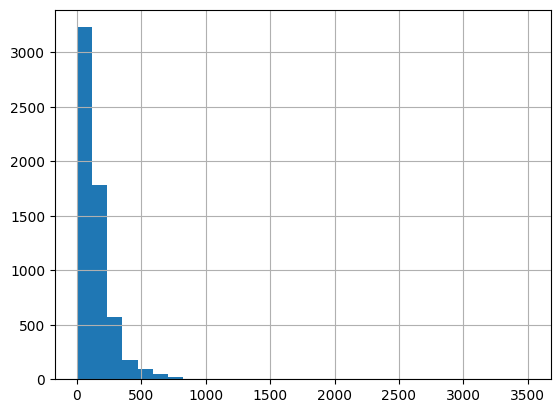

In [17]:
df['longueur'] = df['avis nettoye'].apply(lambda x: len(x.split()))
df['longueur'].hist(bins=30)

In [18]:
# Sauvegarde des donnees pretraitees
df.to_csv('../data/avis_pretraite.csv', index=False)

In [19]:
pd.read_csv('../data/avis_pretraite.csv').head()

,avis_clients,avis nettoye,lang,tokens,text_lemmas,longueur
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"['spa', 'proposer', 'traitement', 'signatur', ...",spa proposer traitement signatur exclusif deve...,20
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"['sejour', 'correct', 'justifier', 'pleinement...",sejour correct justifier pleinement classement...,23
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"['exposition', 'collection', 'art', 'contempor...",exposition collection art contemporain hotel p...,13
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"['emplacement', 'privilegie', 'parfaire', 'exp...",emplacement privilegie parfaire explorer ville...,24
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"['petit', 'dejeuner', 'buffet', 'varier', 'raf...",petit dejeuner buffet varier raffine reapprovi...,18
